
# Transportation & Mobility Visualization with City2Graph

This notebook demonstrates how to create transportation and mobility visualizations using `city2graph`:

1. **Travel Summary Graph** - Visualization of transit connections from GTFS data
2. **OD Matrix Graph** - Origin-Destination flow visualization from ridership data

We'll use NYC subway data as an example, following the same data structure as the NYC challenge notebook.

## 1. Import Required Libraries

In [1]:
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from shapely import wkt
from shapely.geometry import Point, box

import city2graph as c2g

# Set plotting style
plt.style.use("default")
get_ipython().run_line_magic('matplotlib', 'inline')

## 2. Define Data Paths

Data files are expected to be in the `data/` directory:
- `data/gtfs_subway.zip` - GTFS feed for subway system
- `data/MTA_Subway_Origin-Destination_Ridership_Estimate.csv` - OD ridership data

In [2]:
# Define data paths
DATA_DIR = Path("data")
GTFS_PATH = DATA_DIR / "gtfs_subway.zip"
OD_DATA_PATH = DATA_DIR / "MTA_Subway_Origin-Destination_Ridership_Estimate__Beginning_2025.csv"

# Check if files exist
print(f"GTFS data exists: {GTFS_PATH.exists()}")
print(f"OD data exists: {OD_DATA_PATH.exists()}")

GTFS data exists: True
OD data exists: True


---
# Travel Summary Graph
 
The travel summary graph represents transit connections derived from GTFS data.
Each node represents a transit stop, and edges represent direct connections with travel time weights.

## 3. Load GTFS Data

In [3]:
gtfs_con = c2g.load_gtfs(str(GTFS_PATH))

print("GTFS database loaded into DuckDB")
tables_df = gtfs_con.execute("SHOW TABLES").df()
print(f"Available GTFS tables: {sorted(tables_df['name'].tolist())}")

GTFS database loaded into DuckDB
Available GTFS tables: ['agency', 'calendar', 'calendar_dates', 'routes', 'shapes', 'stop_times', 'stops', 'transfers', 'trips']


In [4]:
# Peek at calendar rows via DuckDB SQL
gtfs_con.execute("SELECT * FROM calendar LIMIT 5").df()

,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,Sunday,0,0,0,0,0,0,1,20251102,20251207
1,Saturday,0,0,0,0,0,1,0,20251102,20251207
2,Weekday,1,1,1,1,1,0,0,20251102,20251207


## 4. Create Travel Summary Graph

In [5]:
travel_summary_nodes, travel_summary_edges = c2g.travel_summary_graph(
    gtfs_con,
    start_time="06:00:00",
    end_time="10:00:00",
    calendar_start="20251103",
    calendar_end="20251103",
    as_nx=False,
    directed=False,
    use_frequencies=True,
 )

In [6]:
# Exclude nodes and edges of Staten Island
# Staten Island bounding box (approximate): lon -74.26 to -74.04, lat 40.48 to 40.65
staten_island_bbox = box(-74.26, 40.48, -74.04, 40.65)

# Filter out nodes that are within Staten Island
travel_summary_nodes = travel_summary_nodes[
    ~travel_summary_nodes.geometry.within(staten_island_bbox)
]

# Get the list of valid node IDs (not in Staten Island)
valid_node_ids = set(travel_summary_nodes.index)

# Filter edges where both source and target are valid (not in Staten Island)
# The edges dataframe has a MultiIndex, so we access levels from the index
edge_sources = travel_summary_edges.index.get_level_values(0)
edge_targets = travel_summary_edges.index.get_level_values(1)
travel_summary_edges = travel_summary_edges[
    edge_sources.isin(valid_node_ids) &
    edge_targets.isin(valid_node_ids)
]

print(f"Nodes after filtering: {len(travel_summary_nodes)}")
print(f"Edges after filtering: {len(travel_summary_edges)}")

# Create NetworkX graph from filtered nodes and edges
travel_summary_G = c2g.gdf_to_nx(travel_summary_nodes, travel_summary_edges)
print("Travel Summary Graph Statistics:")
print(f"  Number of nodes: {travel_summary_G.number_of_nodes()}")
print(f"  Number of edges: {travel_summary_G.number_of_edges()}")

Nodes after filtering: 1425
Edges after filtering: 1071
Travel Summary Graph Statistics:
  Number of nodes: 1425
  Number of edges: 551


/Users/yutasato/Projects/paper_1/city2graph-case-study/.venv/lib/python3.12/site-packages/city2graph/base.py:813: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  return gdf.geometry.centroid


## 5. Visualize Travel Summary Graph

In [7]:
travel_nodes, travel_edges = c2g.nx_to_gdf(travel_summary_G)
travel_nodes_plot = travel_nodes.to_crs(epsg=3857)
travel_edges_plot = travel_edges.to_crs(epsg=3857)

# Hourly frequency
travel_edges_plot["frequency"] = travel_edges_plot["frequency"] / 4

<Axes: >

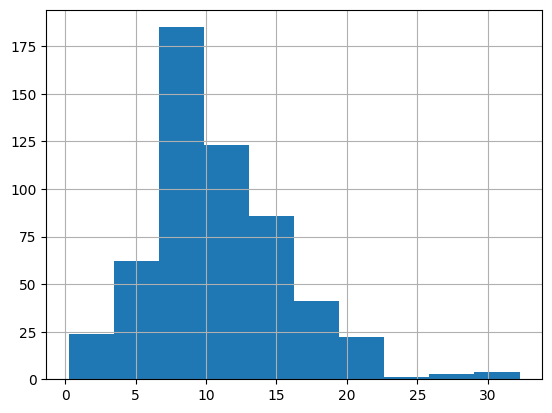

In [8]:
travel_edges_plot["frequency"].hist()

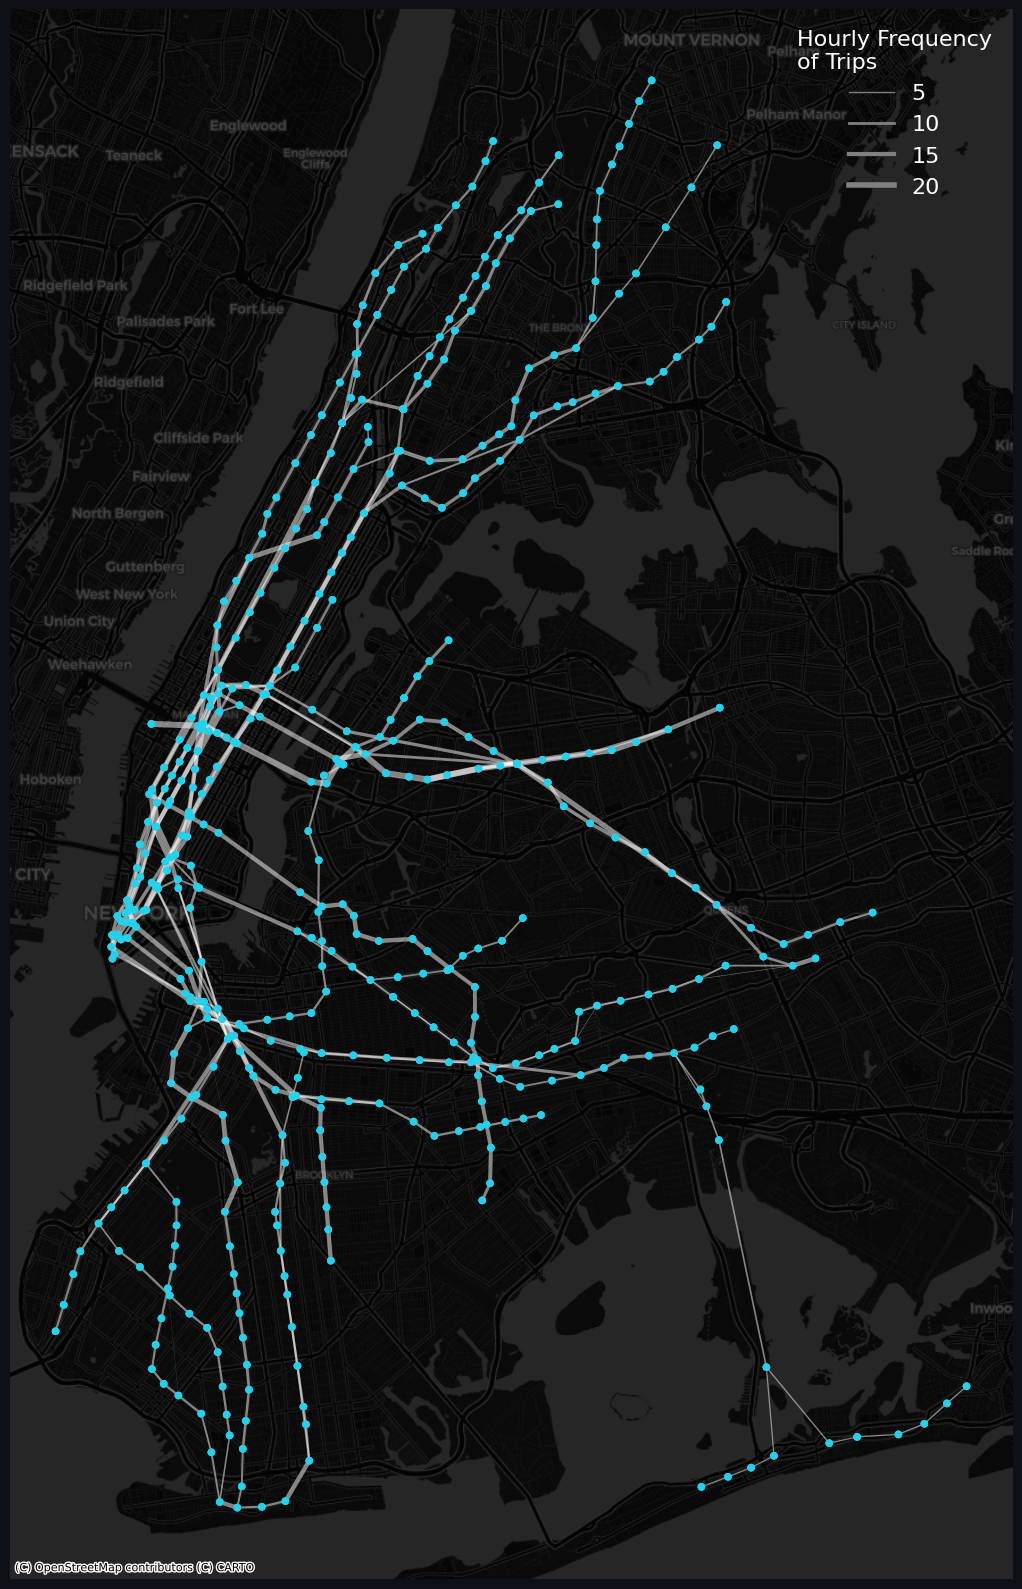

In [9]:
# Create figure with dark theme
fig, ax = plt.subplots(figsize=(16, 16))

# Plot using city2graph's plot_graph with attribute mapping
c2g.plot_graph(
    nodes=travel_nodes_plot,
    edges=travel_edges_plot,
    ax=ax,
    bgcolor='#0d1117',
    # Node styling
    node_alpha=0.9,
    markersize=30,
    # Edge styling
    edge_color='travel_time_sec',      # Map color to frequency
    #cmap='plasma',               # Use high-contrast colormap
    edge_linewidth=travel_edges_plot['frequency']/5,  # Scaled widths
    edge_alpha=0.5,
)


# Add legend for edge linewidth
legend_values = [5, 10, 15, 20]

legend_elements = [
    Line2D([0], [0], color='gray', lw=val/5, label=f'{val}')
    for val in legend_values
]
leg = ax.legend(
    handles=legend_elements, 
    title="Hourly Frequency\nof Trips ", 
    loc="upper right", 
    frameon=False, 
    labelcolor='white',
    fontsize=16,
    title_fontsize=16
)
plt.setp(leg.get_title(), color='white')
# Add dark basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter, zoom=12)

# Style the plot
ax.set_axis_off()
plt.tight_layout()
plt.savefig("transportation.jpg", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


# OD Matrix Graph

The Origin-Destination (OD) matrix graph represents flow patterns between locations.
Each node represents a station/zone, and edges represent ridership flows weighted by volume.

## 6. Load OD Matrix Data

In [10]:
# Load MTA subway OD data
print(f"Loading OD data from: {OD_DATA_PATH}")
od_data = pd.read_csv(OD_DATA_PATH)

print(f"\nOD data shape: {od_data.shape}")
print(f"\nColumns: {od_data.columns.tolist()}")
print("\nFirst few rows:")
display(od_data.head())

Loading OD data from: data/MTA_Subway_Origin-Destination_Ridership_Estimate__Beginning_2025.csv

OD data shape: (127671, 7)

Columns: ['Origin Station Complex Name', 'Destination Station Complex Name', 'Origin Station Complex ID', 'Destination Station Complex ID', 'Origin Point', 'Destination Point', 'avg_estimated_average_ridership']

First few rows:


,Origin Station Complex Name,Destination Station Complex Name,Origin Station Complex ID,Destination Station Complex ID,Origin Point,Destination Point,avg_estimated_average_ridership
0,Beach 44 St (A),Grand St (L),206,123,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926),0.323000
1,"30 Av (N,W)","Simpson St (2,5)",3,430,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073),0.569267
2,"Northern Blvd (M,R)",2 Av (F),269,232,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402),1.531520
3,Pelham Pkwy (5),"Grand Central-42 St (S,4,5,6,7)",445,610,POINT (-73.855359 40.858985),POINT (-73.977359 40.751992),20.349060
4,80 St (A),New Lots Av (L),190,136,POINT (-73.858992 40.679371),POINT (-73.899232 40.658733),1.031250


## 7. Extract Unique Station Locations

In [11]:
# Extract unique stations with their geometries from OD data
if od_data is not None:
    stations = {}

    # Process origin stations
    for idx, row in od_data.iterrows():
        station_name = row["Origin Station Complex Name"]
        if station_name not in stations:
            point_str = row["Origin Point"]
            point = wkt.loads(point_str)
            stations[station_name] = {"geometry": point, "lon": point.x, "lat": point.y}

    # Process destination stations
    for idx, row in od_data.iterrows():
        station_name = row["Destination Station Complex Name"]
        if station_name not in stations:
            point_str = row["Destination Point"]
            point = wkt.loads(point_str)
            stations[station_name] = {"geometry": point, "lon": point.x, "lat": point.y}

    # Convert to GeoDataFrame
    stations_df = pd.DataFrame.from_dict(stations, orient="index")
    stations_df["station_name"] = stations_df.index

    stations_gdf = gpd.GeoDataFrame(
        stations_df,
        geometry="geometry",
        crs="EPSG:4326",  # WGS84
    )

    # Reproject to NYC local CRS (NAD83 / New York Long Island)
    stations_gdf = stations_gdf.to_crs(epsg=2263)

    print(f"Total unique stations: {len(stations_gdf)}")
    print(f"CRS: {stations_gdf.crs}")
    print("\nFirst few stations:")
    display(stations_gdf.head())
else:
    stations_gdf = None
    print("OD data not available.")

Total unique stations: 424
CRS: EPSG:2263

First few stations:


,geometry,lon,lat,station_name
Beach 44 St (A),POINT (1046456.966 155381.067),-73.776013,40.592943,Beach 44 St (A)
"30 Av (N,W)",POINT (1006000.556 218644.773),-73.921479,40.766779,"30 Av (N,W)"
"Northern Blvd (M,R)",POINT (1010292.054 213586.957),-73.906006,40.752885,"Northern Blvd (M,R)"
Pelham Pkwy (5),POINT (1024260.514 252262),-73.855359,40.858985,Pelham Pkwy (5)
80 St (A),POINT (1023360.896 186821.07),-73.858992,40.679371,80 St (A)


## 8. Create OD Matrix Graph

In [12]:
# Create OD matrix graph from subway ridership data
print("Creating OD matrix graph...")

od_G = c2g.od_matrix_to_graph(
    od_data,
    zones_gdf=stations_gdf,
    source_col="Origin Station Complex Name",
    target_col="Destination Station Complex Name",
    weight_cols=["avg_estimated_average_ridership"],
    as_nx=True,
)

print("\nOD Matrix Graph Statistics:")
print(f"  Number of stations (nodes): {od_G.number_of_nodes()}")
print(f"  Number of OD pairs (edges): {od_G.number_of_edges()}")

Creating OD matrix graph...

OD Matrix Graph Statistics:
  Number of stations (nodes): 424
  Number of OD pairs (edges): 127671


## 9. Visualize OD Matrix Graph

In [13]:
od_nodes, od_edges = c2g.nx_to_gdf(od_G)
od_nodes_plot = od_nodes.to_crs(epsg=3857)
od_edges_plot = od_edges.to_crs(epsg=3857)

In [14]:
# Make sure avg_estimated_average_ridership is between 0.01 to 0.99 quantiles
od_edges_plot = od_edges_plot[
    (od_edges_plot['avg_estimated_average_ridership'] >= od_edges_plot['avg_estimated_average_ridership'].quantile(0.01)) &
    (od_edges_plot['avg_estimated_average_ridership'] <= od_edges_plot['avg_estimated_average_ridership'].quantile(0.99))
]

In [15]:
# Make sure avg_estimated_average_ridership is between 0.01 to 0.99 quantiles
od_edges_plot = od_edges_plot[
    (od_edges_plot['avg_estimated_average_ridership'] >= 1)
]

In [16]:
od_edges_plot['avg_estimated_average_ridership'].describe()

count    46460.000000
mean         3.892651
std          4.393907
min          1.000000
25%          1.334000
50%          2.071837
75%          4.345260
max         27.282140
Name: avg_estimated_average_ridership, dtype: float64

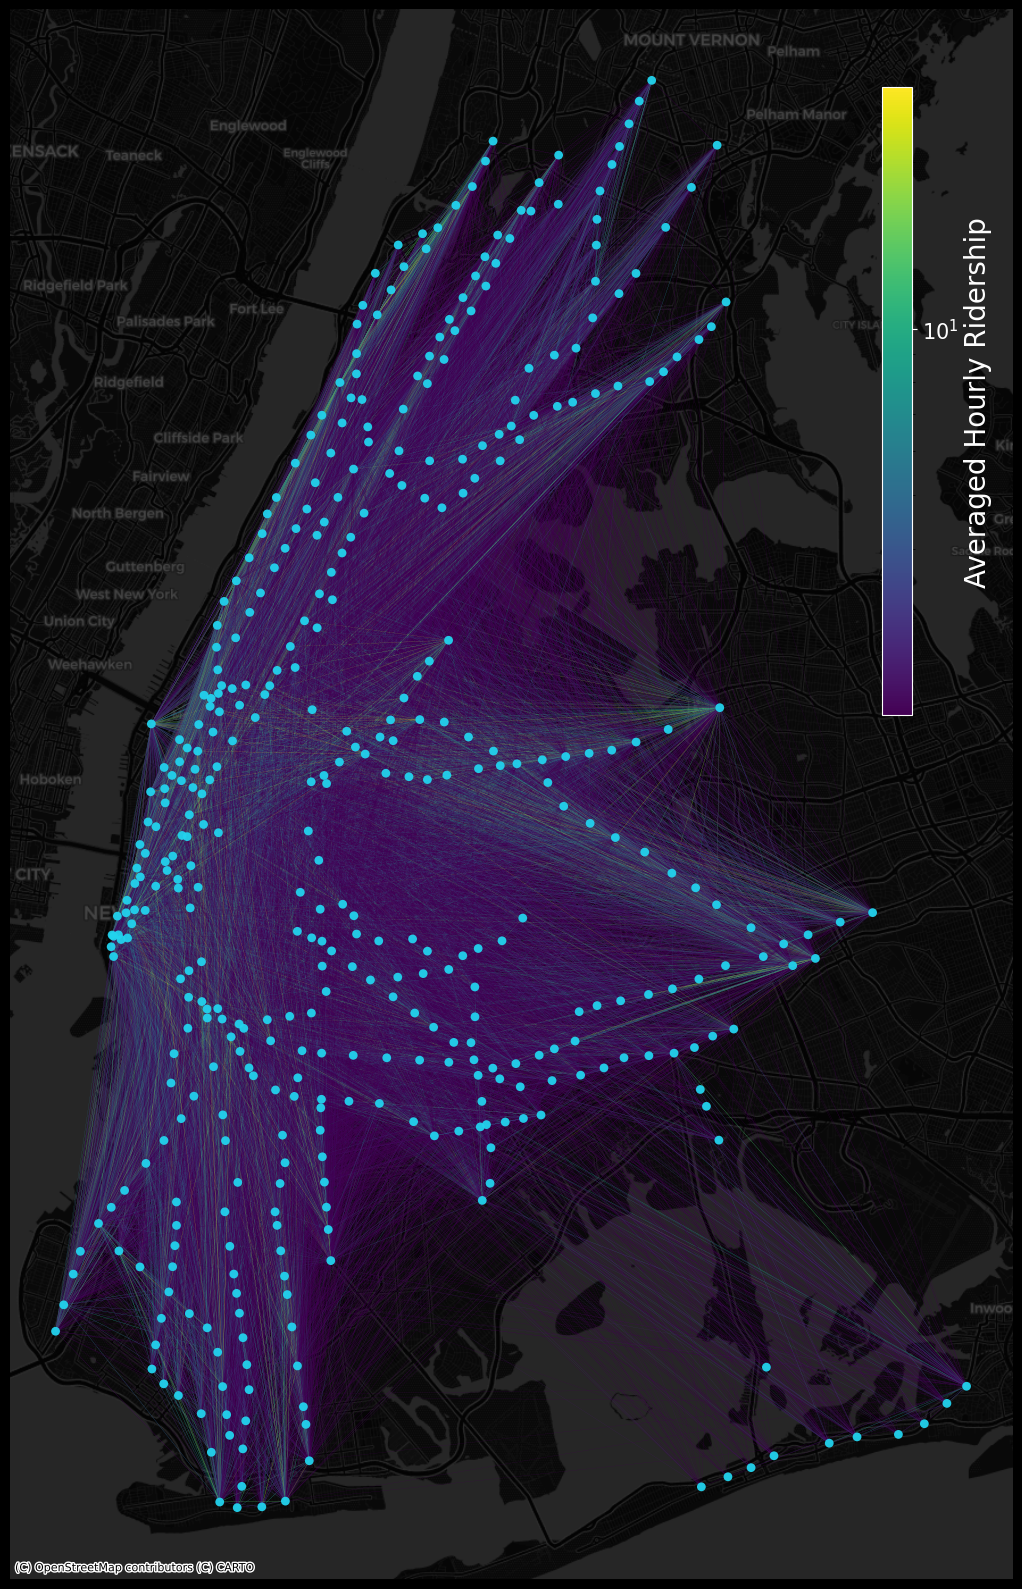

In [17]:
# Create another version of the OD matrix plot with edges colored by ridership
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create figure with dark theme
fig, ax = plt.subplots(figsize=(16, 16), facecolor='black')

# Prepare colormap based on ridership
ridership = od_edges_plot['avg_estimated_average_ridership']
# Use LogNorm to handle skewed distribution and better visualize variations
norm = mcolors.LogNorm(vmin=ridership.min() + 1, vmax=ridership.max())
cmap = cm.viridis  # sequential (reviewer request)

# Create scalar mappable for colorbar and edge colors
m = cm.ScalarMappable(norm=norm, cmap=cmap)
edge_colors = [mcolors.to_hex(color) for color in m.to_rgba(ridership)]

# Reuse edge widths from previous cell or recalculate if needed
# Ensure consistent width scaling
width_scale = 0.5
edge_widths = np.log1p(ridership) * width_scale

# Plot using city2graph's plot_graph
c2g.plot_graph(
    nodes=od_nodes_plot,
    edges=od_edges_plot,
    ax=ax,
    # Node styling
    node_alpha=0.95,
    markersize=40,
    # Edge styling
    edge_linewidth=0.1,
    edge_color=edge_colors,
    edge_alpha=1
)

# Create inset axes for colorbar inside the plot
# [x, y, width, height] relative to parent axes
cax = ax.inset_axes([0.87, 0.55, 0.03, 0.4])

# Add colorbar to the inset axes
cbar = plt.colorbar(m, cax=cax)
cbar.set_label('Averaged Hourly Ridership', color='white', fontsize=20)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=15)
cbar.outline.set_edgecolor('white')

# Add dark basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter, zoom=12)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("mobility.jpg", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [29]:
from cmcrameri import cm as cmc
from matplotlib.colors import LinearSegmentedColormap

base = cmc.davos.reversed()

def truncate(c, lo=0.2, hi=1, n=256):
    return LinearSegmentedColormap.from_list("trunc", c(np.linspace(lo, hi, n)))

cmap = cmc.davos #cm.viridis

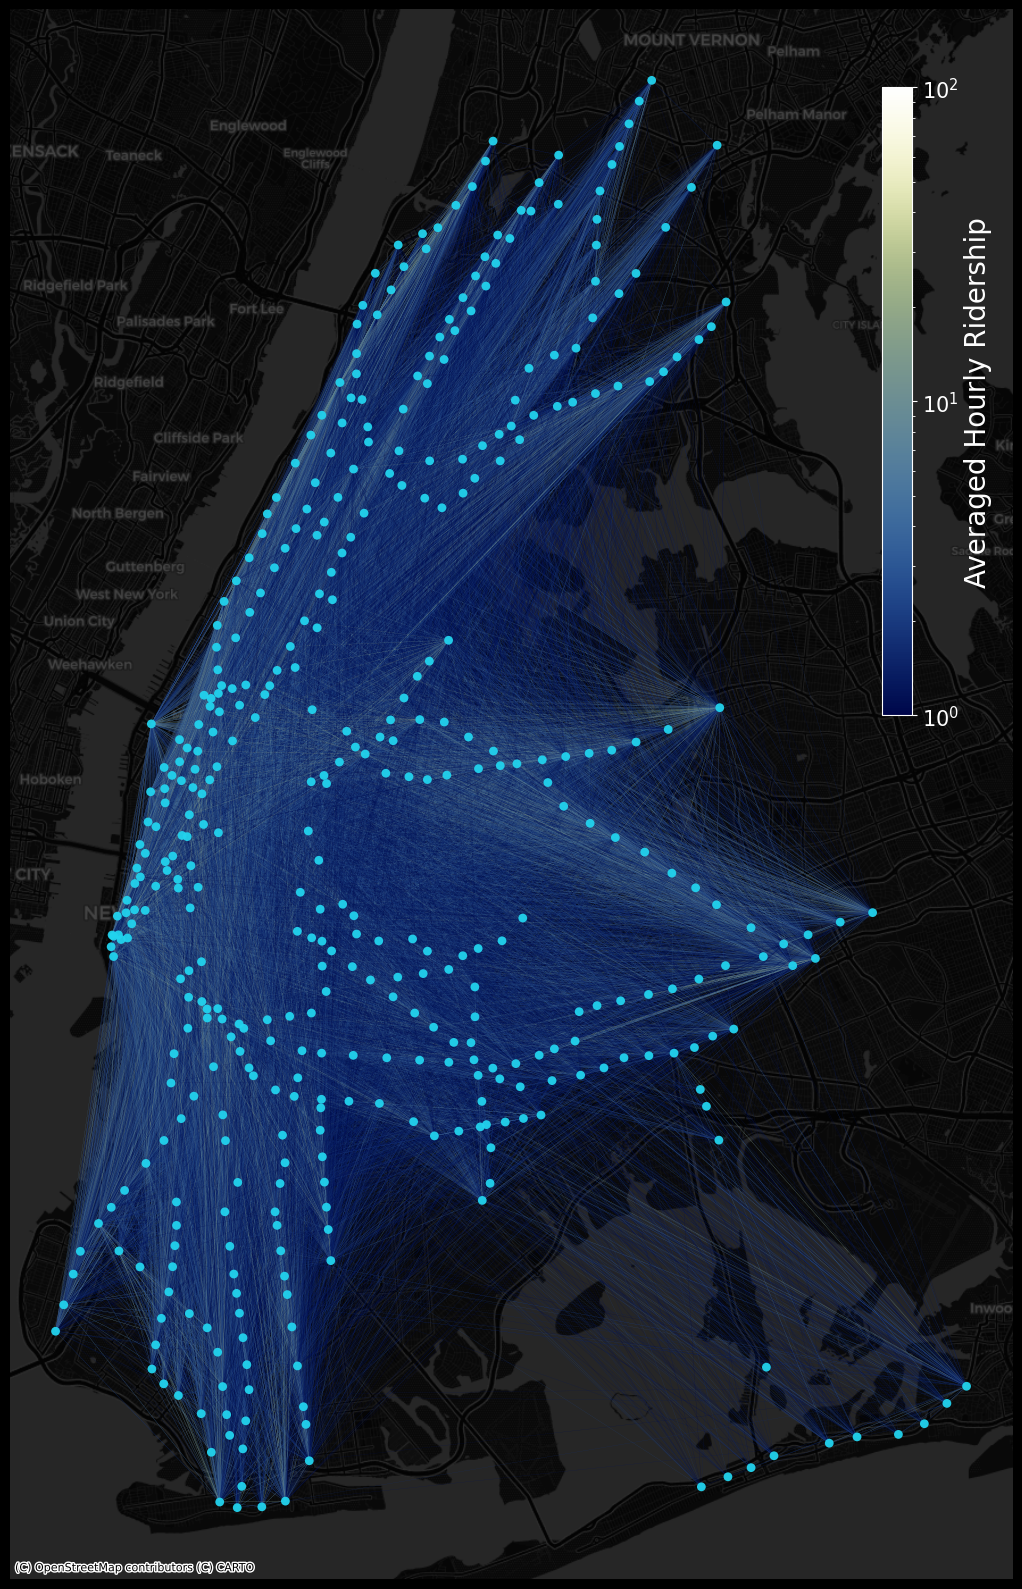

In [33]:
# OD matrix plot with edges coloured by ridership (log-scaled colorbar)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.ticker import FixedLocator, LogLocator, LogFormatterSciNotation
import contextily as cx
import city2graph as c2g

from cmcrameri import cm as cmc

# --- Prepare ridership values ---------------------------------------------
ridership = od_edges_plot['avg_estimated_average_ridership']
r_valid = ridership[np.isfinite(ridership) & (ridership > 0)]

# Fix the colour scale to span 10^0 .. 10^2 so the three decades are meaningful
vmin = 1.0      # 10^0
vmax = 100.0    # 10^2

# LogNorm with a clean decade range
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = cmc.davos

# Scalar mappable for both edge colours and the colorbar (same norm -> consistent)
m = cm.ScalarMappable(norm=norm, cmap=cmap)
edge_colors = [mcolors.to_hex(c) for c in m.to_rgba(ridership)]

# Edge widths (consistent log scaling)
width_scale = 0.5
edge_widths = np.log1p(ridership) * width_scale

# --- Figure ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 16), facecolor='black')

# Plot using city2graph's plot_graph
c2g.plot_graph(
    nodes=od_nodes_plot,
    edges=od_edges_plot,
    ax=ax,
    # Node styling
    node_alpha=0.95,
    markersize=40,
    # Edge styling
    edge_linewidth=0.1,
    edge_color=edge_colors,
    edge_alpha=1,
)

# --- Colorbar (inset) ------------------------------------------------------
# [x, y, width, height] relative to parent axes
cax = ax.inset_axes([0.87, 0.55, 0.03, 0.4])
cbar = plt.colorbar(m, cax=cax)

# Force exactly three major ticks: 10^0, 10^1, 10^2
cbar.ax.yaxis.set_major_locator(FixedLocator([1, 10, 100]))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
# Keep minor tick marks but no minor labels
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs='all'))
cbar.ax.yaxis.set_minor_formatter(plt.NullFormatter())

# Label / styling
cbar.set_label('Averaged Hourly Ridership', color='white', fontsize=20)
cbar.ax.yaxis.set_tick_params(which='major', color='white', labelcolor='white', labelsize=15)
cbar.ax.yaxis.set_tick_params(which='minor', color='white', labelcolor='white', labelsize=15)
cbar.outline.set_edgecolor('white')

# --- Basemap & export ------------------------------------------------------
cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter, zoom=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mobility.jpg", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()